Dataset shape: (32561, 15)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:43:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Accuracy: 0.8793182865039152


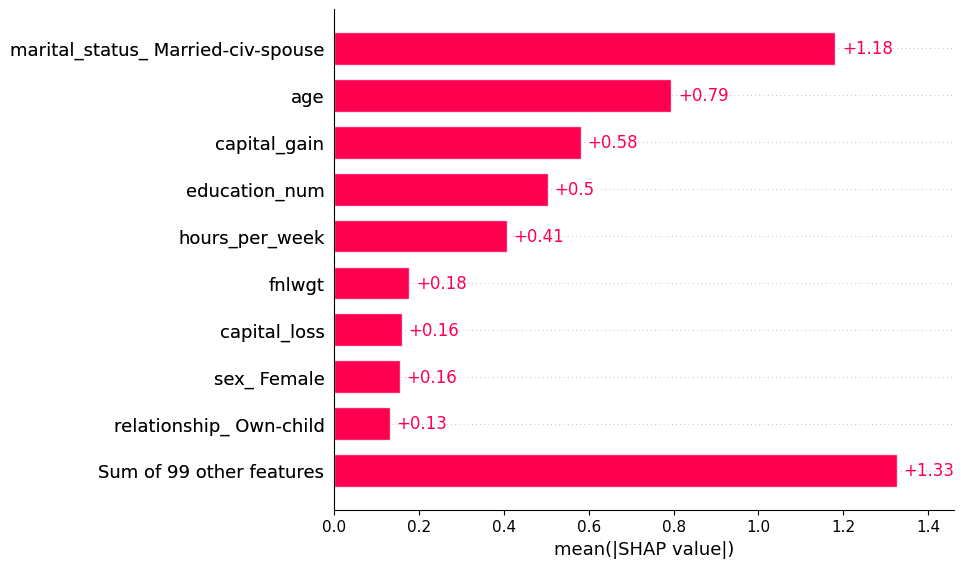

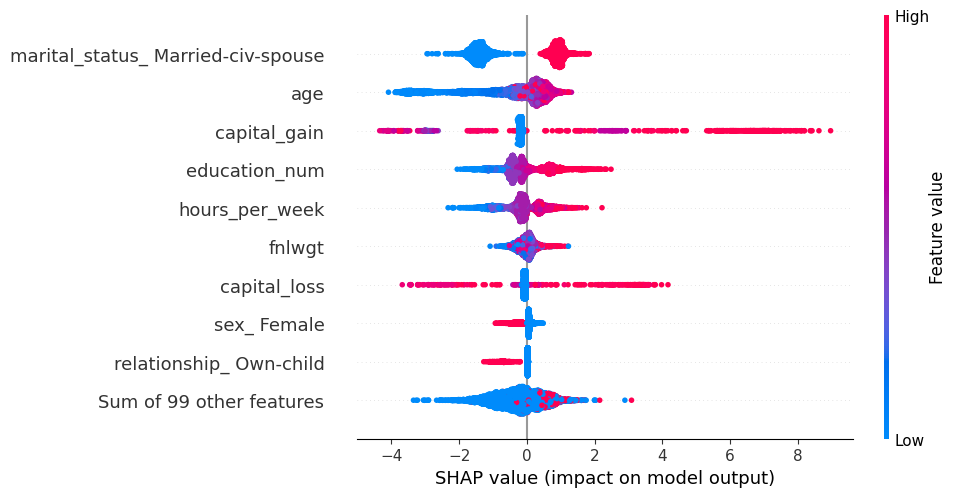

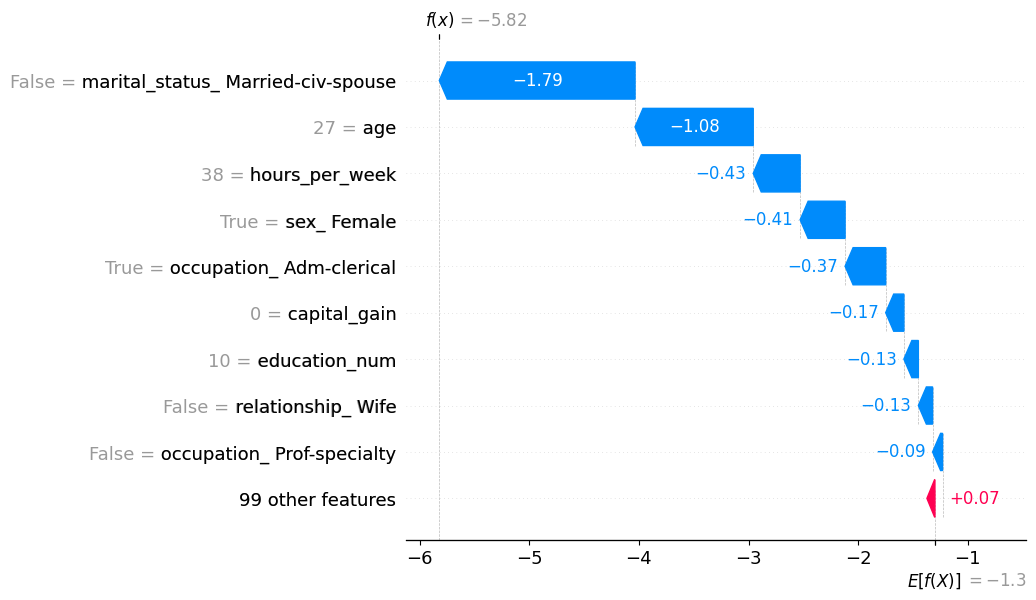

In [5]:
# Install libraries
!pip install xgboost shap
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
# -----------------------------
# Load Dataset: Adult Census Income
# -----------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
 "age","workclass","fnlwgt","education","education_num","marital_status","occupation","relationship","race","sex",
 "capital_gain","capital_loss","hours_per_week","native_country","income"
]

df = pd.read_csv(url, names=columns)

# Preview our dataset
print("Dataset shape:", df.shape)
df.head()

# -----------------------------
# Data Cleaning
# -----------------------------
df = df.dropna()

X = df.drop("income", axis=1)
y = df["income"]

# Convert income target variable to numerical values for XGBoost
y = y.map({' <=50K': 0, ' >50K': 1})

# Convert categorical variables to dummy variables (0 and 1s)
X = pd.get_dummies(X)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Model Training
# -----------------------------
model = XGBClassifier(use_label_encoder = False, eval_metric = "logloss")
model.fit(X_train, y_train)

# -----------------------------
# Model Evaluation/Accuracy
# -----------------------------
pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, pred))

# -----------------------------
# SHAP Explainability
# -----------------------------
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Feature Importance Plot
shap.plots.bar(shap_values)
# Beeswarm Plot
shap.plots.beeswarm(shap_values)
# Example Individual Prediction
shap.plots.waterfall(shap_values[0])






